In [14]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nba_api.stats.endpoints import leaguedashplayershotlocations

print("Ready")

Ready


In [15]:
shot_data = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
    season='2025-26',
    season_type_all_star='Regular Season'
)
df = shot_data.get_data_frames()[0]
print(df.shape)
print(df.columns.tolist())

(582, 30)
[('', np.str_('PLAYER_ID')), ('', np.str_('PLAYER_NAME')), ('', np.str_('TEAM_ID')), ('', np.str_('TEAM_ABBREVIATION')), ('', np.str_('AGE')), ('', np.str_('NICKNAME')), (np.str_('Restricted Area'), np.str_('FGM')), (np.str_('Restricted Area'), np.str_('FGA')), (np.str_('Restricted Area'), np.str_('FG_PCT')), (np.str_('In The Paint (Non-RA)'), np.str_('FGM')), (np.str_('In The Paint (Non-RA)'), np.str_('FGA')), (np.str_('In The Paint (Non-RA)'), np.str_('FG_PCT')), (np.str_('Mid-Range'), np.str_('FGM')), (np.str_('Mid-Range'), np.str_('FGA')), (np.str_('Mid-Range'), np.str_('FG_PCT')), (np.str_('Left Corner 3'), np.str_('FGM')), (np.str_('Left Corner 3'), np.str_('FGA')), (np.str_('Left Corner 3'), np.str_('FG_PCT')), (np.str_('Right Corner 3'), np.str_('FGM')), (np.str_('Right Corner 3'), np.str_('FGA')), (np.str_('Right Corner 3'), np.str_('FG_PCT')), (np.str_('Above the Break 3'), np.str_('FGM')), (np.str_('Above the Break 3'), np.str_('FGA')), (np.str_('Above the Break 3'

In [16]:
df.columns = ['_'.join(col).strip('_') for col in df.columns]
print(df.columns.tolist())

['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'AGE', 'NICKNAME', 'Restricted Area_FGM', 'Restricted Area_FGA', 'Restricted Area_FG_PCT', 'In The Paint (Non-RA)_FGM', 'In The Paint (Non-RA)_FGA', 'In The Paint (Non-RA)_FG_PCT', 'Mid-Range_FGM', 'Mid-Range_FGA', 'Mid-Range_FG_PCT', 'Left Corner 3_FGM', 'Left Corner 3_FGA', 'Left Corner 3_FG_PCT', 'Right Corner 3_FGM', 'Right Corner 3_FGA', 'Right Corner 3_FG_PCT', 'Above the Break 3_FGM', 'Above the Break 3_FGA', 'Above the Break 3_FG_PCT', 'Backcourt_FGM', 'Backcourt_FGA', 'Backcourt_FG_PCT', 'Corner 3_FGM', 'Corner 3_FGA', 'Corner 3_FG_PCT']


In [17]:
zones = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Corner 3', 'Above the Break 3']
league_avg={}
for zone in zones:
    fgm_col = f'{zone}_FGM'
    fga_col = f'{zone}_FGA'
    total_fgm = df[fgm_col].sum()
    total_fga = df[fga_col].sum()
    league_avg[zone] = round(total_fgm/total_fga, 3) if total_fga > 0 else 0
print(league_avg)


{'Restricted Area': np.float64(0.671), 'In The Paint (Non-RA)': np.float64(0.446), 'Mid-Range': np.float64(0.417), 'Corner 3': np.float64(0.387), 'Above the Break 3': np.float64(0.35)}


In [18]:
def calc_expected_fg(row):
    total_fga = 0
    total_expected_makes = 0
    for zone in zones:
        fga = row[f'{zone}_FGA']
        total_fga += fga
        total_expected_makes += fga * league_avg[zone]
    if total_fga > 0:
        return round(total_expected_makes / total_fga, 3)
    return 0

df['expected_fg_pct'] = df.apply(calc_expected_fg, axis=1)

def calc_actual_fg(row):
    total_fgm = sum(row[f'{zone}_FGM'] for zone in zones)
    total_fga = sum(row[f'{zone}_FGA'] for zone in zones)
    return round(total_fgm / total_fga, 3) if total_fga > 0 else 0

df['actual_fg_pct'] = df.apply(calc_actual_fg, axis=1)

print(df[['PLAYER_NAME', 'expected_fg_pct', 'actual_fg_pct']].head(10))

     PLAYER_NAME  expected_fg_pct  actual_fg_pct
0    A.J. Lawson            0.484          0.436
1       AJ Green            0.375          0.424
2     AJ Johnson            0.515          0.324
3   Aaron Gordon            0.482          0.497
4  Aaron Holiday            0.407          0.417
5  Aaron Nesmith            0.438          0.414
6  Aaron Wiggins            0.465          0.431
7     Ace Bailey            0.446          0.443
8      Adama Bal            0.430          0.412
9      Adem Bona            0.632          0.595


In [19]:
df['fg_diff'] = round(df['actual_fg_pct'] - df['expected_fg_pct'], 3)

df_filtered = df[df['Restricted Area_FGA'] + df['In The Paint (Non-RA)_FGA'] + 
                   df['Mid-Range_FGA'] + df['Corner 3_FGA'] + 
                   df['Above the Break 3_FGA'] >= 150]

print(f"Players with 150+ shot attempts: {len(df_filtered)}")
print(df_filtered[['PLAYER_NAME', 'expected_fg_pct', 'actual_fg_pct', 'fg_diff']].sort_values('fg_diff', ascending=False).head(10))

Players with 150+ shot attempts: 385
             PLAYER_NAME  expected_fg_pct  actual_fg_pct  fg_diff
272         Jericho Sims            0.644          0.784    0.140
258         Jaxson Hayes            0.625          0.756    0.131
487     Ryan Kalkbrenner            0.633          0.753    0.120
137        Deandre Ayton            0.561          0.671    0.110
230         Jakob Poeltl            0.593          0.700    0.107
374         Luke Kennard            0.429          0.533    0.104
478  Robert Williams III            0.609          0.708    0.099
333         Kevin Durant            0.428          0.520    0.092
429         Nikola Jokić            0.483          0.569    0.086
32          Anthony Gill            0.542          0.628    0.086


In [20]:
print(df_filtered[['PLAYER_NAME', 'expected_fg_pct', 'actual_fg_pct', 'fg_diff']].sort_values('fg_diff', ascending=True).head(10))

         PLAYER_NAME  expected_fg_pct  actual_fg_pct  fg_diff
2         AJ Johnson            0.515          0.324   -0.191
172  Elijah Harkless            0.459          0.335   -0.124
41         Ben Saraf            0.515          0.396   -0.119
397      Micah Peavy            0.501          0.385   -0.116
225   Jahmai Mashack            0.489          0.395   -0.094
369       Lonzo Ball            0.395          0.301   -0.094
437     Nolan Traore            0.473          0.380   -0.093
97      Clint Capela            0.611          0.520   -0.091
430     Nikola Jović            0.455          0.366   -0.089
477   Rob Dillingham            0.483          0.396   -0.087


# Beyond the Box Score — Shot Quality and Selection Analysis

Not all shots are created equal. A shot at the rim converts at roughly 67%, while a mid-range jumper converts at just 41.7%. Both count as two points. When accounting for both make rate and point value, rim attempts and three-point attempts represent the two highest value shots in basketball, while long twos and mid-range shots represent the lowest. Free throws are the most efficient scoring opportunity in the sport, which is part of why aggressive rim attacks are valued, they often draw fouls in addition to generating easy points. This project focuses specifically on field goal attempts to build a model that separates shot selection from shot making, answering not just "is a player efficient," but "is a player efficient because of good decisions, good talent, or both."

## Section 1: Shot Value by Zone

Every shot has an inherent value based on its expected points per attempt, a combination of how often it goes in and how many points it's worth. The chart below shows league-average expected points per shot across the five main shot zones, based on 2025-26 NBA shot location data.

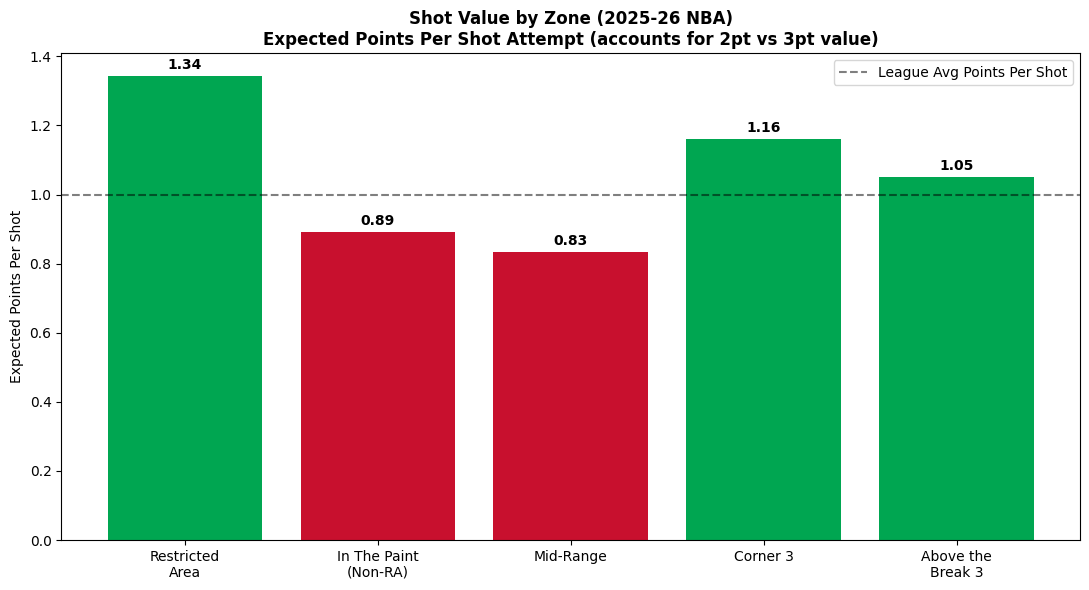

In [21]:
zone_labels = ['Restricted\nArea', 'In The Paint\n(Non-RA)', 'Mid-Range', 
                'Corner 3', 'Above the\nBreak 3']
zone_values = [league_avg['Restricted Area'], league_avg['In The Paint (Non-RA)'], 
                league_avg['Mid-Range'], league_avg['Corner 3'], 
                league_avg['Above the Break 3']]
zone_points = [2, 2, 2, 3, 3]
expected_value = [v * p for v, p in zip(zone_values, zone_points)]

colors_val = ['#00A651' if v >= 1.0 else '#C8102E' for v in expected_value]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(zone_labels, expected_value, color=colors_val)
ax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5, label='League Avg Points Per Shot')
ax.set_title('Shot Value by Zone (2025-26 NBA)\nExpected Points Per Shot Attempt (accounts for 2pt vs 3pt value)', 
             fontsize=12, fontweight='bold')
ax.set_ylabel('Expected Points Per Shot')
ax.legend()

for bar, val in zip(bars, expected_value):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('nba_shot_value_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 2: Building a Shot Quality Model

Using shot location data from every NBA player in the 2025-26 season, this model calculates each player's Expected Field Goal Percentage, what they should shoot based purely on where their attempts came from, using league-average conversion rates for each zone. Comparing that number to a player's Actual Field Goal Percentage isolates shot-making ability from shot selection. A player above the diagonal line is outperforming their shot quality; a player below it is underperforming, even if their shot selection is sound.

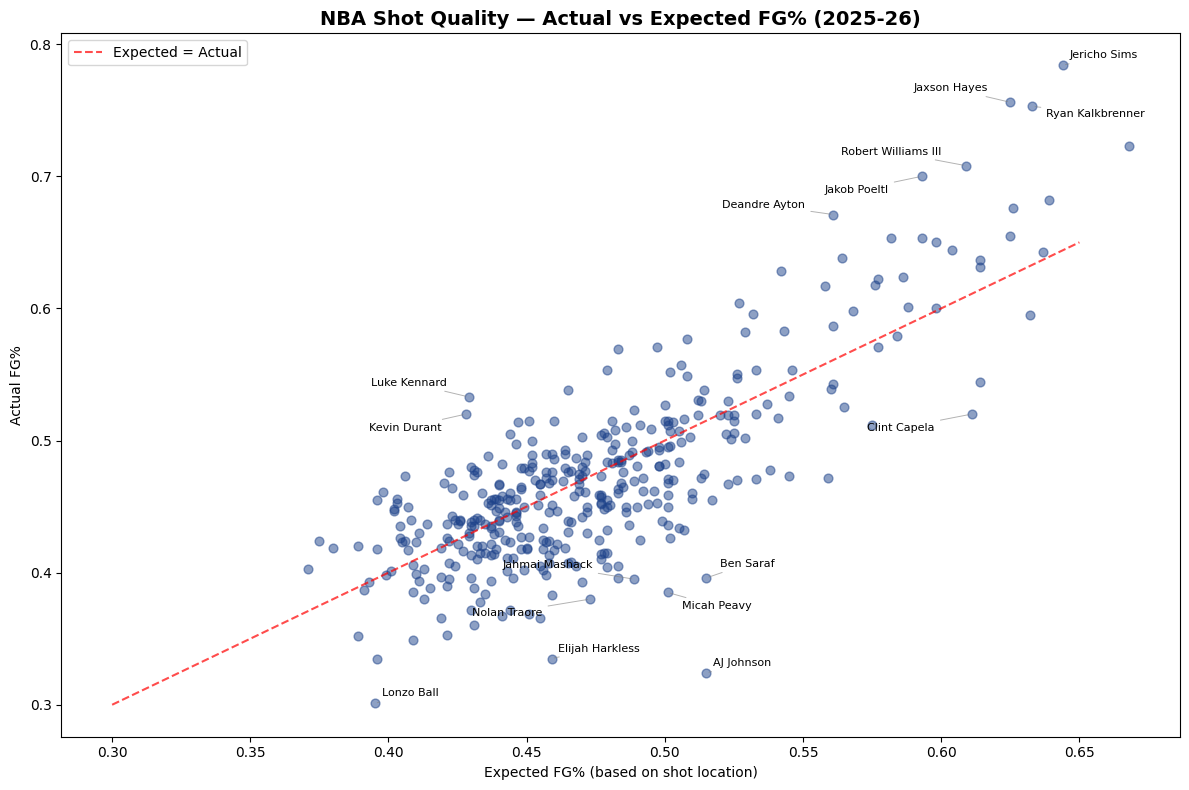

In [22]:
top_over = df_filtered.sort_values('fg_diff', ascending=False).head(8)
top_under = df_filtered.sort_values('fg_diff', ascending=True).head(8)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df_filtered['expected_fg_pct'], df_filtered['actual_fg_pct'], 
           alpha=0.5, color='#1D428A', s=40)

ax.plot([0.3, 0.65], [0.3, 0.65], color='red', linestyle='--', alpha=0.7, label='Expected = Actual')
players_to_label = list(top_over['PLAYER_NAME']) + list(top_under['PLAYER_NAME'])

for _, row in df_filtered.iterrows():
    if row['PLAYER_NAME'] in players_to_label:
        offset = label_offsets.get(row['PLAYER_NAME'], (5, 5))
        ax.annotate(row['PLAYER_NAME'], 
                    xy=(row['expected_fg_pct'], row['actual_fg_pct']),
                    xytext=offset, textcoords='offset points', 
                    fontsize=8,
                    arrowprops=dict(arrowstyle='-', color='gray', alpha=0.6, lw=0.7))
ax.set_title('NBA Shot Quality — Actual vs Expected FG% (2025-26)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Expected FG% (based on shot location)')
ax.set_ylabel('Actual FG%')
ax.legend()

plt.tight_layout()
plt.savefig('nba_shot_quality_scatter.png', dpi=150, bbox_inches='tight')

## Section 3: Shot Selection Score

Shot Selection Score ranks players purely by shot location quality, independent of whether they actually made the shot. It rewards attempts at the rim and from the corners, the two highest value locations on the floor, and penalizes long 2 PT attempts. This metric is naturally dominated by centers and rim-runners, since restricted area shots carry the highest expected value in basketball. That's an intentional limitation worth noting: this measures decision-making quality, not overall offensive skill or shot creation difficulty. Rankings throughout this section are limited to players with at least 150 total shot attempts this season, to reduce noise from small sample sizes.

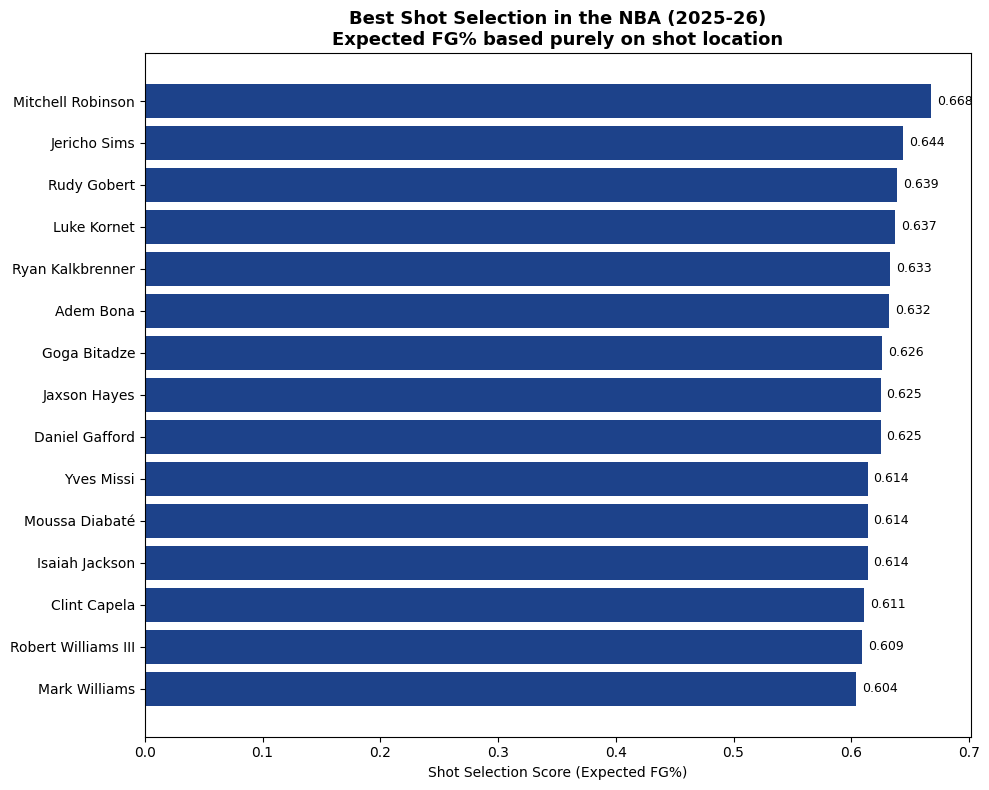

In [23]:
def calc_shot_selection_score(row):
    total_fga = sum(row[f'{zone}_FGA'] for zone in zones)
    if total_fga == 0:
        return 0
    score = sum(row[f'{zone}_FGA'] * league_avg[zone] for zone in zones) / total_fga
    return round(score, 3)

df_filtered = df_filtered.copy()
df_filtered['shot_selection_score'] = df_filtered.apply(calc_shot_selection_score, axis=1)

top_selection = df_filtered.sort_values('shot_selection_score', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top_selection['PLAYER_NAME'], top_selection['shot_selection_score'], color='#1D428A')
ax.set_title('Best Shot Selection in the NBA (2025-26)\nExpected FG% based purely on shot location', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Shot Selection Score (Expected FG%)')
ax.invert_yaxis()

for bar, val in zip(bars, top_selection['shot_selection_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('nba_shot_selection_score.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 4: Overperformers and Underperformers

Combining shot quality and shot making surfaces two important groups. Overperformers are players making shots at a higher rate than their shot selection alone would predict, either elite shot makers or players getting hot. Underperformers have reasonable shot selection but aren't converting at the expected rate, which isolates a shooting or finishing issue separate from decision-making. This distinction matters for player development: it tells you whether to coach shot selection or shot mechanics.

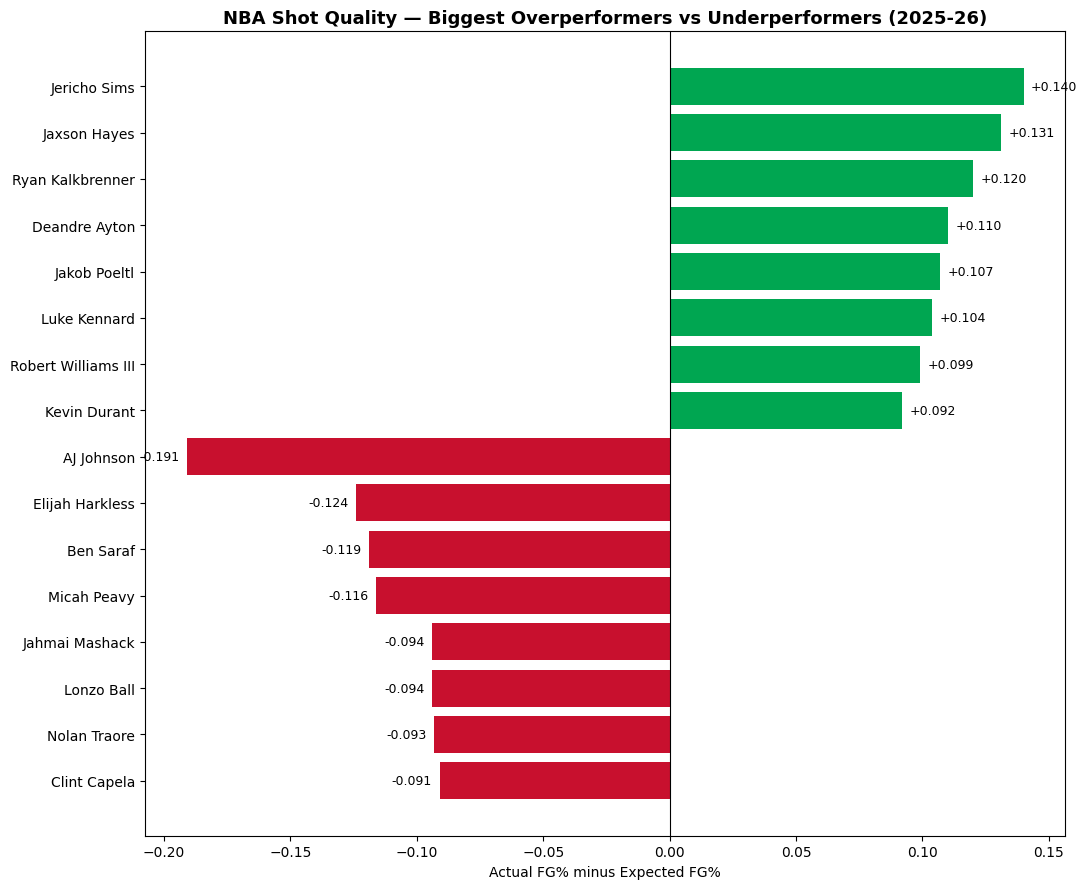

In [24]:
top_over = df_filtered.sort_values('fg_diff', ascending=False).head(8)
top_under = df_filtered.sort_values('fg_diff', ascending=True).head(8)

combined = pd.concat([top_over, top_under])

colors = ['#00A651' if x > 0 else '#C8102E' for x in combined['fg_diff']]

fig, ax = plt.subplots(figsize=(11, 9))
bars = ax.barh(combined['PLAYER_NAME'], combined['fg_diff'], color=colors)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('NBA Shot Quality — Biggest Overperformers vs Underperformers (2025-26)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual FG% minus Expected FG%')
ax.invert_yaxis()

for bar, val in zip(bars, combined['fg_diff']):
    label_x = bar.get_width() + 0.003 if val > 0 else bar.get_width() - 0.003
    ha = 'left' if val > 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2, f'{val:+.3f}', 
            va='center', ha=ha, fontsize=9)

plt.tight_layout()
plt.savefig('nba_over_under_performers.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
gleague_shot_data = leaguedashplayershotlocations.LeagueDashPlayerShotLocations(
    season='2025-26',
    season_type_all_star='Regular Season',
    league_id_nullable='20'
)

df_gleague = gleague_shot_data.get_data_frames()[0]
print(df_gleague.shape)

(526, 30)


In [26]:
df_gleague.columns = ['_'.join(col).strip('_') for col in df_gleague.columns]

league_avg_g = {}
for zone in zones:
    fgm_col = f'{zone}_FGM'
    fga_col = f'{zone}_FGA'
    total_fgm = df_gleague[fgm_col].sum()
    total_fga = df_gleague[fga_col].sum()
    league_avg_g[zone] = round(total_fgm / total_fga, 3) if total_fga > 0 else 0

print("G-League zone averages:")
print(league_avg_g)
print("\nNBA zone averages:")
print(league_avg)

G-League zone averages:
{'Restricted Area': np.float64(0.669), 'In The Paint (Non-RA)': np.float64(0.453), 'Mid-Range': np.float64(0.389), 'Corner 3': np.float64(0.385), 'Above the Break 3': np.float64(0.345)}

NBA zone averages:
{'Restricted Area': np.float64(0.671), 'In The Paint (Non-RA)': np.float64(0.446), 'Mid-Range': np.float64(0.417), 'Corner 3': np.float64(0.387), 'Above the Break 3': np.float64(0.35)}


In [27]:
def calc_expected_fg_g(row):
    total_fga = 0
    total_expected_makes = 0
    for zone in zones:
        fga = row[f'{zone}_FGA']
        total_fga += fga
        total_expected_makes += fga * league_avg_g[zone]
    if total_fga > 0:
        return round(total_expected_makes / total_fga, 3)
    return 0

df_gleague['expected_fg_pct'] = df_gleague.apply(calc_expected_fg_g, axis=1)

def calc_actual_fg_g(row):
    total_fgm = sum(row[f'{zone}_FGM'] for zone in zones)
    total_fga = sum(row[f'{zone}_FGA'] for zone in zones)
    return round(total_fgm / total_fga, 3) if total_fga > 0 else 0

df_gleague['actual_fg_pct'] = df_gleague.apply(calc_actual_fg_g, axis=1)
df_gleague['fg_diff'] = round(df_gleague['actual_fg_pct'] - df_gleague['expected_fg_pct'], 3)

print(df_gleague[['PLAYER_NAME', 'expected_fg_pct', 'actual_fg_pct', 'fg_diff']].head(10))

       PLAYER_NAME  expected_fg_pct  actual_fg_pct  fg_diff
0      A.J. Lawson            0.473          0.462   -0.011
1       AJ Hoggard            0.480          0.428   -0.052
2       AJ Johnson            0.470          0.404   -0.066
3      Aaron Scott            0.442          0.469    0.027
4     Abou Ousmane            0.593          0.515   -0.078
5  Ace Baldwin Jr.            0.454          0.440   -0.014
6     Adam Flagler            0.442          0.423   -0.019
7        Adama Bal            0.409          0.396   -0.013
8      Adou Thiero            0.531          0.625    0.094
9      Ahmad Caver            0.430          0.405   -0.025


In [28]:
gleague_total_fga = (df_gleague['Restricted Area_FGA'] + df_gleague['In The Paint (Non-RA)_FGA'] + 
                       df_gleague['Mid-Range_FGA'] + df_gleague['Corner 3_FGA'] + 
                       df_gleague['Above the Break 3_FGA'])

df_gleague_filtered = df_gleague[gleague_total_fga >= 100]

top_gleague_over = df_gleague_filtered.sort_values('fg_diff', ascending=False).head(10)
print(top_gleague_over[['PLAYER_NAME', 'expected_fg_pct', 'actual_fg_pct', 'fg_diff']])

        PLAYER_NAME  expected_fg_pct  actual_fg_pct  fg_diff
268   Josiah Allick            0.563          0.681    0.118
43     Bronny James            0.454          0.560    0.106
449    Steven Crowl            0.590          0.693    0.103
104  Dakota Mathias            0.394          0.493    0.099
378  Nick Smith Jr.            0.413          0.511    0.098
71   Charles Bassey            0.508          0.606    0.098
282   Kaleb Johnson            0.548          0.639    0.091
49       CJ Huntley            0.522          0.613    0.091
525     Zyon Pullin            0.494          0.583    0.089
187     Isaih Moore            0.587          0.675    0.088


## Section 5: Applying the Model to the G-League

The same framework applied to G-League shot location data reveals the two levels are very similar in shooting efficiency across most zones, with one notable exception. Mid-range shooting is roughly 3 percentage points worse in the G-League (38.9% vs. 41.7% in the NBA), suggesting that shot-making touch on tougher, contested jumpers is one of the more meaningful gaps between the two levels.

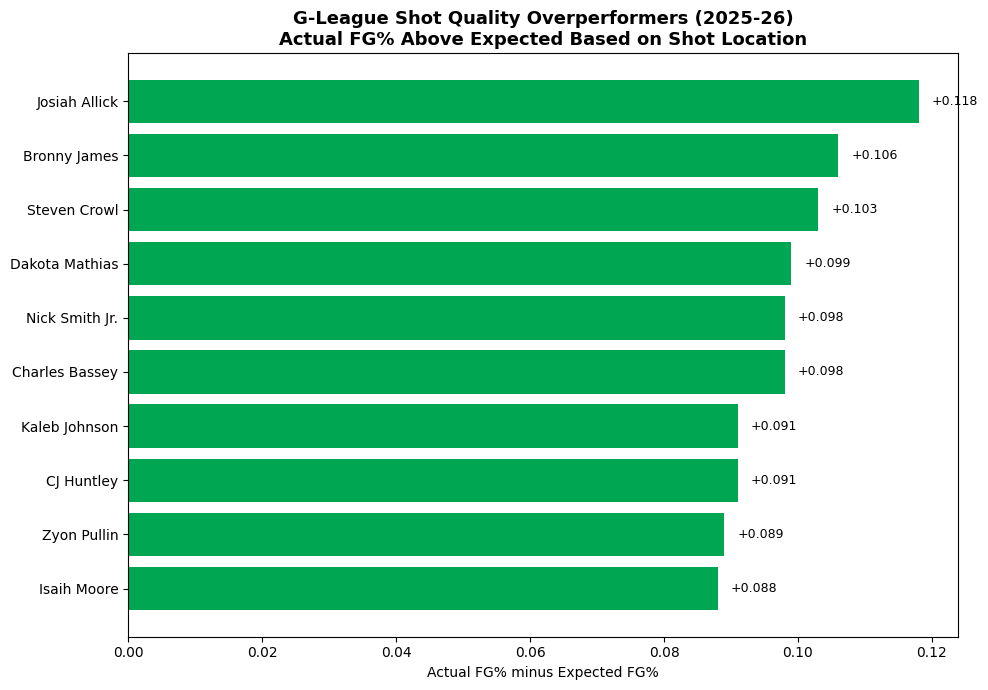

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_gleague_over['PLAYER_NAME'], top_gleague_over['fg_diff'], color='#00A651')
ax.set_title('G-League Shot Quality Overperformers (2025-26)\nActual FG% Above Expected Based on Shot Location', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Actual FG% minus Expected FG%')
ax.invert_yaxis()

for bar, val in zip(bars, top_gleague_over['fg_diff']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'+{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('gleague_overperformers.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Case Study — Nick Smith Jr.

Nick Smith Jr., the 27th pick in the 2023 NBA Draft, serves as the case study. After being waived by the Hornets and playing on a two-way deal with the Lakers, the Lakers recently declined his team option, making him an unrestricted free agent. His 2025-26 G-League shot profile shows a player whose shot-making has outpaced his shot quality by location, a data point worth considering as he looks for his next opportunity. Note: at 227 attempts, this analysis should be read directionally rather than definitively, as individual location samples can be noisy at this volume.

![Nick Smith Jr Heat Map](nick_smith_heatmap.png)

![Nick Smith Jr Shot Chart](nick_smith_shotchart.png)

## Closing Note

Traditional box score stats fail to separate shot selection from shot making, this model can. For player development purposes, that distinction determines whether a coaching staff should be working on in-game decision-making scenarios or take a more foundational approach and work on things like mechanics and footwork. Applied at scale, this framework offers a repeatable way to evaluate where a player's efficiency is actually coming from.

**Data Sources**
- NBA Stats API (nba_api): shot location data for NBA and G-League players, 2025-26 season